# Day 2 - Feature Engineering and Exploratory Data Analysis

## Objective

In this notebook, I will perform Feature Engineering and Exploratory Data Analysis (EDA) on the cleaned dataset from Day 1.

### Tasks
- Load the cleaned dataset
- Explore the dataset
- Create useful new features
- Convert categorical columns using One-Hot Encoding
- Perform Exploratory Data Analysis
- Create a correlation heatmap
- Create distribution plots
- Export the final feature-engineered dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cleaned_dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1.0,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1.0,0,PC 17599,65.6344,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0.0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1.0,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0.0,0,373450,8.0500,Unknown,S


print("Jupyter is working!")

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp          float64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [5]:
# Create new features

# Family size = number of siblings/spouses + parents/children + passenger
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Check whether the passenger was traveling alone
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Fare paid per family member
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

# Extract passenger title from the Name column
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

# Display the new features
df[["FamilySize", "IsAlone", "FarePerPerson", "Title"]].head()

,FamilySize,IsAlone,FarePerPerson,Title
0,2.0,0,3.6250,Mr
1,2.0,0,32.8172,Mrs
2,1.0,1,7.9250,Miss
3,2.0,0,26.5500,Mrs
4,1.0,1,8.0500,Mr


## Feature Engineering

Feature engineering is the process of creating new meaningful features from existing data.

In this dataset, I created:

- **FamilySize:** Total number of family members traveling with the passenger.
- **IsAlone:** Indicates whether a passenger was traveling alone.
- **FarePerPerson:** Calculates the fare paid per family member.
- **Title:** Extracts the passenger's title from their name.

These features can provide additional information that is not directly available from the original columns.

## Datetime Feature Extraction

The cleaned dataset does not contain a datetime/date column. Therefore, extracting day, month, or weekday features is not applicable to this dataset. No artificial datetime values were created because that would not represent real information in the data.

In [6]:
# One-Hot Encoding for categorical features

df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True,
    dtype=int
)

# Remove high-cardinality text columns that are not useful for numerical analysis
df = df.drop(columns=["Name", "Ticket", "Cabin"])

df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,1,0,3,22.0,1.0,0,7.2500,2.0,0,3.6250,...,0,0,0,0,1,0,0,0,0,0
1,2,1,1,38.0,1.0,0,65.6344,2.0,0,32.8172,...,0,0,0,0,0,1,0,0,0,0
2,3,1,3,26.0,0.0,0,7.9250,1.0,1,7.9250,...,0,1,0,0,0,0,0,0,0,0
3,4,1,1,35.0,1.0,0,53.1000,2.0,0,26.5500,...,0,0,0,0,0,1,0,0,0,0
4,5,0,3,35.0,0.0,0,8.0500,1.0,1,8.0500,...,0,0,0,0,1,0,0,0,0,0


In [7]:
print("Final Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Final Dataset Shape: (891, 29)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Sex_Male', 'Embarked_Q', 'Embarked_S', 'Title_Col', 'Title_Don', 'Title_Dr', 'Title_Jonkheer', 'Title_Lady', 'Title_Major', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rev', 'Title_Sir', 'Title_the Countess']

Data Types:
PassengerId             int64
Survived                int64
Pclass                  int64
Age                   float64
SibSp                 float64
Parch                   int64
Fare                  float64
FamilySize            float64
IsAlone                 int64
FarePerPerson         float64
Sex_Male                int64
Embarked_Q              int64
Embarked_S              int64
Title_Col               int64
Title_Don               int64
Title_Dr                int64
Title_Jonkheer          int64
Title_Lady              int64
Title_Major             in

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and visualizing a dataset to understand patterns, relationships, distributions, and possible trends.

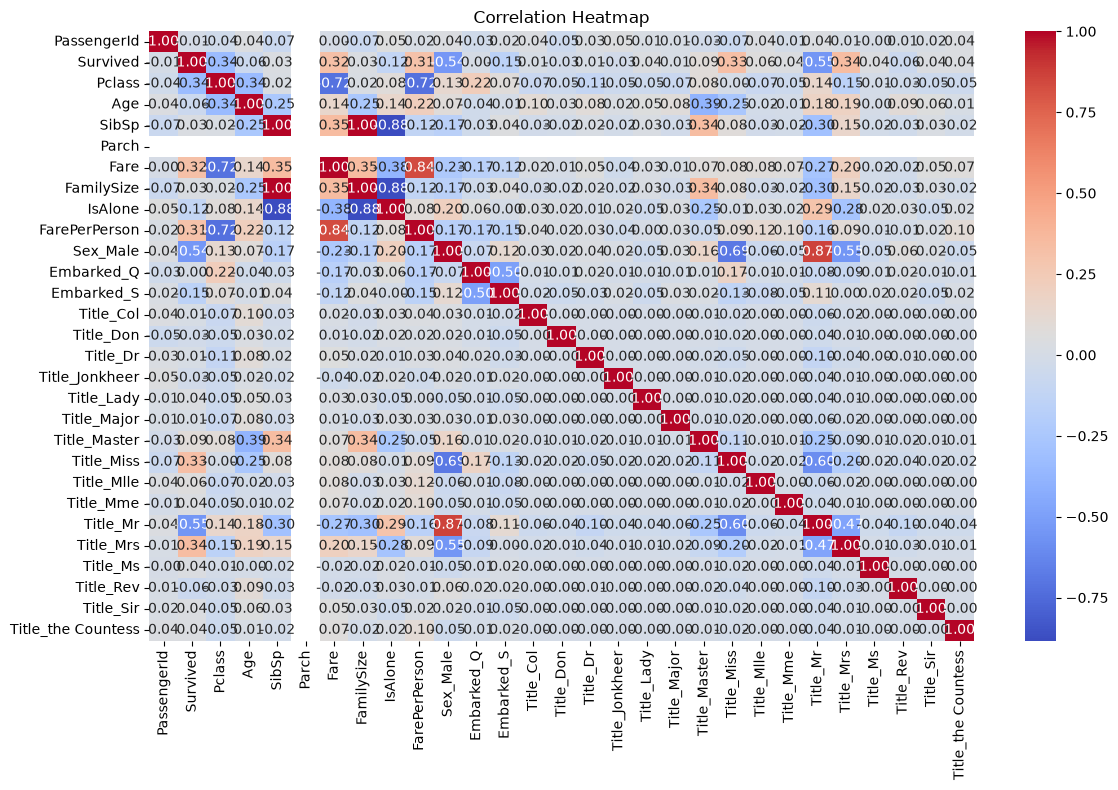

In [8]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Distribution Plot 1: Age

The age distribution shows how passengers are distributed across different age groups.

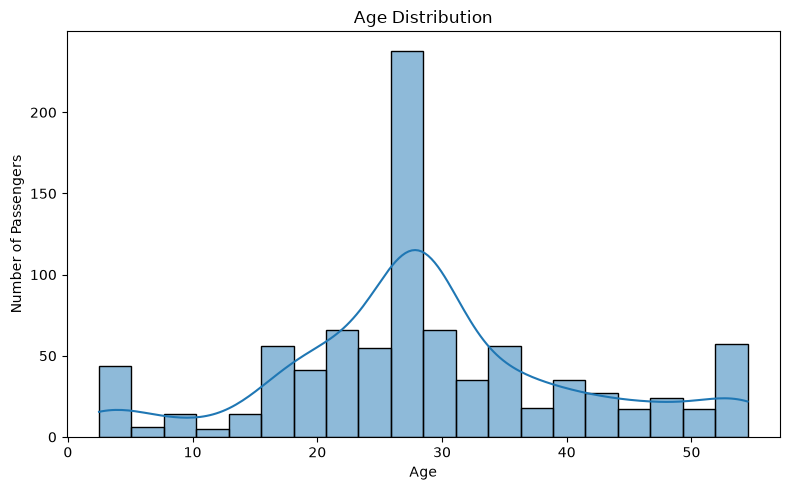

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

## Distribution Plot 2: Fare

The fare distribution shows how the ticket prices were distributed among passengers.

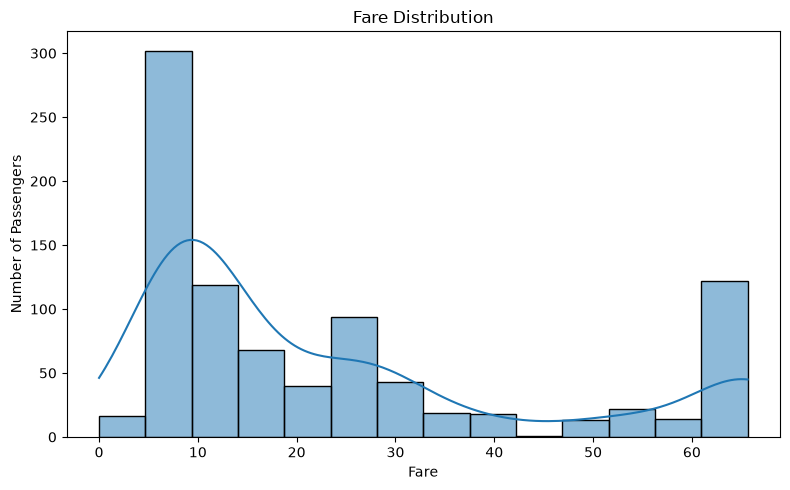

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Fare"], kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

In [11]:
print(correlation["Survived"].sort_values(ascending=False))

Survived              1.000000
Title_Mrs             0.339040
Title_Miss            0.327093
Fare                  0.317430
FarePerPerson         0.307578
Title_Master          0.085221
Title_Mlle            0.060095
Title_Lady            0.042470
Title_Mme             0.042470
Title_Ms              0.042470
Title_the Countess    0.042470
Title_Sir             0.042470
SibSp                 0.031434
FamilySize            0.031434
Title_Major           0.011329
Title_Col             0.011329
Title_Dr              0.008185
Embarked_Q            0.003650
PassengerId          -0.005007
Title_Don            -0.026456
Title_Jonkheer       -0.026456
Age                  -0.060622
Title_Rev            -0.064988
IsAlone              -0.115867
Embarked_S           -0.149683
Pclass               -0.338481
Sex_Male             -0.543351
Title_Mr             -0.549199
Parch                      NaN
Name: Survived, dtype: float64


## EDA Insight

The correlation heatmap shows the relationships between the numerical features and the target variable, Survived. The correlations help identify which variables have stronger or weaker relationships with survival. The heatmap also shows relationships among the other numerical features.

In [12]:
df.to_csv("features_v1.csv", index=False)

print("Feature-engineered dataset successfully saved as features_v1.csv")

Feature-engineered dataset successfully saved as features_v1.csv


In [13]:
print("Final dataset shape:", df.shape)
print("Final dataset columns:", len(df.columns))
print("Missing values:")
print(df.isnull().sum())

Final dataset shape: (891, 29)
Final dataset columns: 29
Missing values:
PassengerId           0
Survived              0
Pclass                0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
FamilySize            0
IsAlone               0
FarePerPerson         0
Sex_Male              0
Embarked_Q            0
Embarked_S            0
Title_Col             0
Title_Don             0
Title_Dr              0
Title_Jonkheer        0
Title_Lady            0
Title_Major           0
Title_Master          0
Title_Miss            0
Title_Mlle            0
Title_Mme             0
Title_Mr              0
Title_Mrs             0
Title_Ms              0
Title_Rev             0
Title_Sir             0
Title_the Countess    0
dtype: int64
